In [5]:
import pandas as pd
import matplotlib.pyplot as plt

data_pad = "/Users/hbraakmann/Desktop/knmi-klimaatscenarios-kerncijfers_landelijk-gemiddelde.csv"

df = pd.read_csv(data_pad, comment="#",header=0, skiprows=3, decimal=",", skipinitialspace=True)

df = df.drop([0, 1, 2]).reset_index(drop=True)
df = df[["Seizoen", "Variabele", "Indicator", "Klimatologie 1991-2020", "2100 Ld", "2100 Ln", "2100 Hd", "2100 Hn"]]
df = df.loc[df["Indicator"] == "gemiddelde"]
df.iloc[0:, 4:8] = df.iloc[0:, 4:8].replace(",", ".", regex=True).replace("°C", "", regex=True).apply(pd.to_numeric, errors="coerce").astype(float)
df

,Seizoen,Variabele,Indicator,Klimatologie 1991-2020,2100 Ld,2100 Ln,2100 Hd,2100 Hn
1,Jaar,Temperatuur,gemiddelde,"10,5°C",0.9,0.9,4.4,4.1
6,Winter,Temperatuur,gemiddelde,"3,9°C",0.7,0.7,3.7,3.9
13,Lente,Temperatuur,gemiddelde,"9,6°C",0.8,0.7,3.6,3.3
18,Zomer,Temperatuur,gemiddelde,"17,3°C",1.2,1.1,5.1,4.7
25,Herfst,Temperatuur,gemiddelde,"11,2°C",1.0,0.9,5.0,4.8


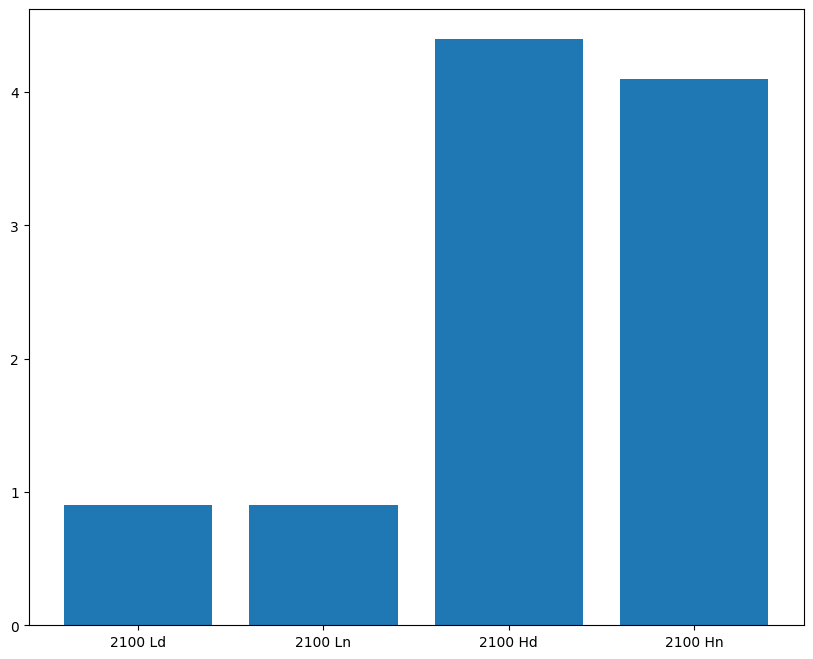

In [7]:
fig , ax = plt.subplots(figsize=(10, 8))

ax.bar(df.iloc[0, 4:8].index, df.iloc[0, 4:8].values)

 

plt.show()

In [129]:
df.iloc[0:, 3:8]

,Klimatologie 1991-2020,2100 Ld,2100 Ln,2100 Hd,2100 Hn
1,10.5°C,11.4°C,11.3°C,14.7°C,14.6°C
6,3.9°C,4.6°C,4.6°C,7.5°C,7.7°C
13,9.6°C,10.4°C,10.4°C,13.1°C,12.8°C
18,17.3°C,18.4°C,18.3°C,22.3°C,21.9°C
25,11.2°C,12.2°C,12.1°C,16.1°C,15.9°C


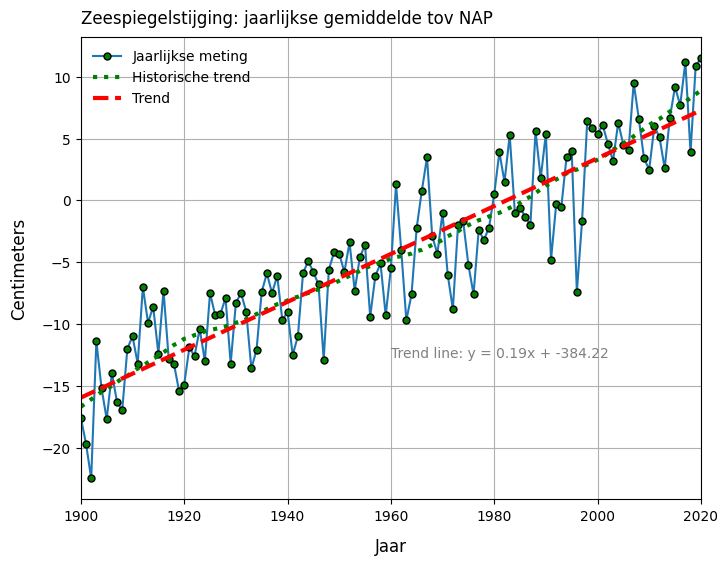

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

data_url = "https://www.deltaprogramma.nl/documenten/publicaties/2023/01/31/downloadpagina-zeespiegelstijging-dashboard-signaalportaal"

df = pd.read_html(data_url, match="Jaarlijkse meting")
zeespiegel_df = df[0]
zeespiegel_df = zeespiegel_df[["Jaar", "Jaarlijkse meting", "Historische trend"]].dropna()
#zeespiegel_df

fig, ax = plt.subplots(figsize=(8, 6))

m = np.polyfit(zeespiegel_df["Jaar"], zeespiegel_df["Jaarlijkse meting"], 1)
trend = np.poly1d(m)

ax.plot(zeespiegel_df["Jaar"], zeespiegel_df["Jaarlijkse meting"], marker=".", markersize=10, mec="black", mfc="green", label="Jaarlijkse meting")
ax.plot(zeespiegel_df["Jaar"], zeespiegel_df["Historische trend"], color="green", linewidth=3, linestyle=":", label="Historische trend")
ax.plot(zeespiegel_df["Jaar"], trend(zeespiegel_df["Jaar"]), color="red", linewidth=3, linestyle="--", label="Trend")

ax.set_title("Zeespiegelstijging: jaarlijkse gemiddelde tov NAP", loc="left", pad=10)
ax.set_xlabel("Jaar", labelpad=10, fontsize=12)
ax.set_ylabel("Centimeters", labelpad=10, fontsize=12)

ax.set_xlim(zeespiegel_df["Jaar"].min(), zeespiegel_df["Jaar"].max())
ax.text(0.5, 0.33, f"Trend line: y = {m[0]:.2f}x + {m[1]:.2f}", transform=ax.transAxes, color="grey", fontsize=10, verticalalignment='top')

ax.grid(axis="both")
ax.legend(frameon=False)
plt.show()

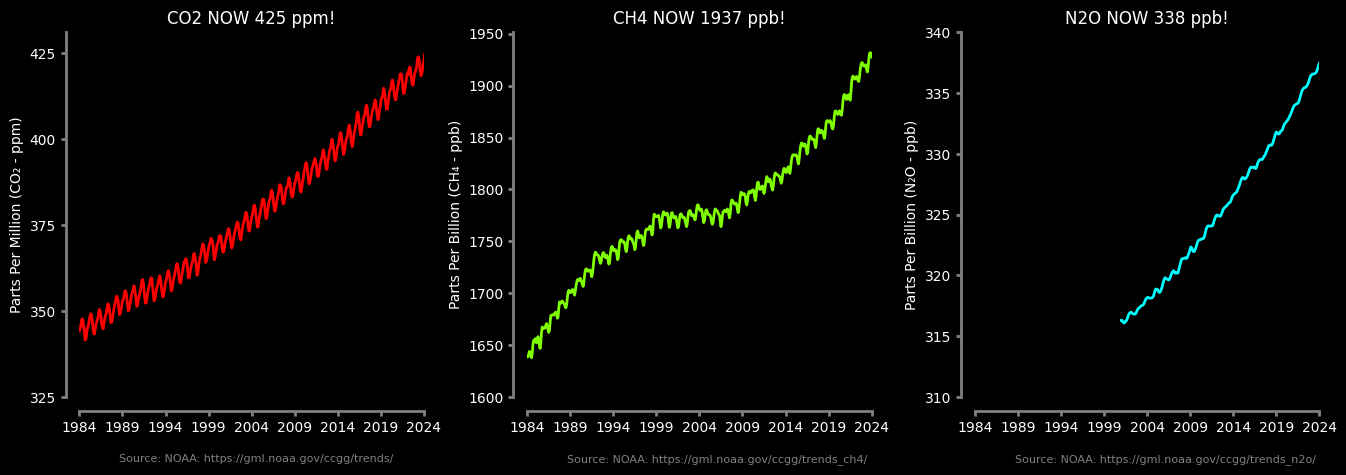

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

data_CO2 = "https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.csv"
data_CH4 = "https://gml.noaa.gov/webdata/ccgg/trends/ch4/ch4_mm_gl.csv"
data_NO2 = "https://gml.noaa.gov/webdata/ccgg/trends/n2o/n2o_mm_gl.csv"

CO2_df = pd.read_csv(data_CO2, comment="#")
CH4_df = pd.read_csv(data_CH4, comment="#")
NO2_df = pd.read_csv(data_NO2, comment="#")


CO2_df = CO2_df.loc[CO2_df["year"]>=1984][["year", "month", "average"]]
CH4_df = CH4_df.loc[CH4_df["year"]>=1984][["year", "month", "average"]]
NO2_df = NO2_df.loc[NO2_df["year"]>=1984][["year", "month", "average"]]

CO2_df["time"] = CO2_df["year"] + (CO2_df["month"] - 1) / 12
CH4_df["time"] = CH4_df["year"] + (CH4_df["month"] - 1) / 12
NO2_df["time"] = NO2_df["year"] + (NO2_df["month"] - 1) / 12

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))


ax1.plot(CO2_df["time"], CO2_df["average"], color="Red", linewidth=2)
ax2.plot(CH4_df["time"], CH4_df["average"], color="Chartreuse", linewidth=2)
ax3.plot(NO2_df["time"], NO2_df["average"], color="Aqua", linewidth=2)

#plot 1
ax1.set_title(f"CO2 NOW {round(CO2_df.iloc[-1].values[2])} ppm!", color="white")
ax1.set_ylabel("Parts Per Million (CO₂ - ppm)", color="white")

ax1.tick_params(axis="both", colors="grey", width=2, labelcolor="white")
ax1.set_xticks(np.arange(1984, 2025, 5))
ax1.set_yticks(np.arange(325, 430, 25))
ax1.set_xlim(CO2_df["year"].min(), CO2_df["year"].max())

ax1.spines[["top", "right"]].set_visible(False)
ax1.spines[["bottom", "left"]].set_color("grey")
ax1.spines[["left", "bottom"]].set_position(("outward", 10))
ax1.spines[["left", "bottom"]].set_linewidth(2)
ax1.set_facecolor("black")


#plot2
ax2.set_title(f"CH4 NOW {round(CH4_df.iloc[-1].values[2])} ppb!", color="white")
ax2.set_ylabel("Parts Per Billion (CH₄ - ppb)", color="white")

ax2.tick_params(axis="both", colors="grey", width=2, labelcolor="white")
ax2.set_xticks(np.arange(1984, 2025, 5))
ax2.set_yticks(np.arange(1600, 2000, 50))
ax2.set_xlim(CH4_df["year"].min(), CH4_df["year"].max())

ax2.spines[["top", "right"]].set_visible(False)
ax2.spines[["bottom", "left"]].set_color("grey")
ax2.spines[["left", "bottom"]].set_position(("outward", 10))
ax2.spines[["left", "bottom"]].set_linewidth(2)
ax2.set_facecolor("black")
                

#plot3
ax3.set_title(f"N2O NOW {round(NO2_df.iloc[-1].values[2])} ppb!", color="white")
ax3.set_ylabel("Parts Per Billion (N₂O - ppb)", color="white")

ax3.tick_params(axis="both", colors="grey", width=2, labelcolor="white")
ax3.set_xticks(np.arange(1984, 2025, 5))
ax3.set_yticks(np.arange(310, 345, 5))
ax3.set_xlim(CH4_df["year"].min(), CH4_df["year"].max())

ax3.set_facecolor("black")
ax3.spines[["bottom", "left"]].set_color("grey")
ax3.spines[["left", "bottom"]].set_position(("outward", 10))
ax3.spines[["left", "bottom"]].set_linewidth(2)

fig.set_facecolor("black")
fig.text(x=0.15, y=0.02, s="Source: NOAA: https://gml.noaa.gov/ccgg/trends/", color="grey", size=8)
fig.text(x=0.43, y=0.02, s="Source: NOAA: https://gml.noaa.gov/ccgg/trends_ch4/", color="grey", size=8)
fig.text(x=0.71, y=0.02, s="Source: NOAA: https://gml.noaa.gov/ccgg/trends_n2o/", color="grey", size=8)

plt.subplots_adjust(wspace=0.3, bottom=0.15)
plt.show()